# Multivariate Cluster Analysis with Validation

## 1. Dataset Upload

In [ ]:
# Upload the dataset file
print("Please upload your movie box office dataset CSV file.")
uploaded = files.upload()

# Read the uploaded CSV file into a pandas DataFrame
# The file is expected to be a CSV, and we use io.BytesIO to read it from memory
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("Dataset uploaded successfully. Displaying the first 5 rows:")
display(df.head())

Please upload your movie box office dataset CSV file.


Saving Tutorial3Data.csv to Tutorial3Data.csv
Dataset uploaded successfully. Displaying the first 5 rows:


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from google.colab import files
import io

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 2. Data Preprocessing

In [ ]:
# Drop the 'Rank' column as it's just an index
df_processed = df.drop(columns=['Rank'])
print(f"Shape after dropping 'Rank' column: {df_processed.shape}")

# Drop rows with missing values in specified categorical and numeric columns
# The numeric columns ($Worldwide, $Domestic, $Foreign, Domestic %, Foreign %, Vote_Count, Year) are crucial and will be handled during feature selection.
# For preprocessing, we focus on categorical features and Vote_Count for initial cleaning.
columns_to_check_for_na = ['Genres', 'Rating', 'Vote_Count', 'Original_Language', 'Production_Countries']
df_processed.dropna(subset=columns_to_check_for_na, inplace=True)
print(f"Shape after dropping rows with missing values: {df_processed.shape}")

# Remove rows where Vote_Count == 0
df_processed = df_processed[df_processed['Vote_Count'] != 0]
print(f"Shape after removing rows with Vote_Count == 0: {df_processed.shape}")

# Define the 5 features for clustering
features_for_clustering = ['$Worldwide', '$Foreign', 'Foreign %', 'Vote_Count', 'Year']

# Create a copy of the dataframe with only the selected features for scaling
X = df_processed[features_for_clustering].copy()

# Convert dollar amount columns to numeric, stripping '$' and ','
for col in ['$Worldwide', '$Domestic', '$Foreign']:
    if col in X.columns:
        X[col] = X[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Apply StandardScaler to normalize all selected numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame from the scaled data
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering, index=X.index)

print("Data preprocessing complete. First 5 rows of scaled features:")
display(X_scaled_df.head())

# Store the processed dataframe for later use (e.g., interpretation)
df_preprocessed_final = df_processed.copy()
# Add scaled features back to the main processed dataframe for consistency if needed later
for col in features_for_clustering:
    df_preprocessed_final[f'{col}_scaled'] = X_scaled_df[col]

Shape after dropping 'Rank' column: (5000, 12)
Shape after dropping rows with missing values: (4797, 12)
Shape after removing rows with Vote_Count == 0: (4781, 12)
Data preprocessing complete. First 5 rows of scaled features:


,$Worldwide,$Foreign,Foreign %,Vote_Count,Year
0,2.075919,1.872314,-0.095001,1.057064,-1.655623
1,1.655438,1.444950,-0.140977,4.162643,-1.655623
2,1.503760,0.879456,-0.587602,2.235016,-1.655623
3,1.231683,0.844884,-0.406981,0.350343,-1.655623
4,1.112656,0.997696,-0.095001,-0.006934,-1.655623


## 3. Finding Optimal Number of Clusters

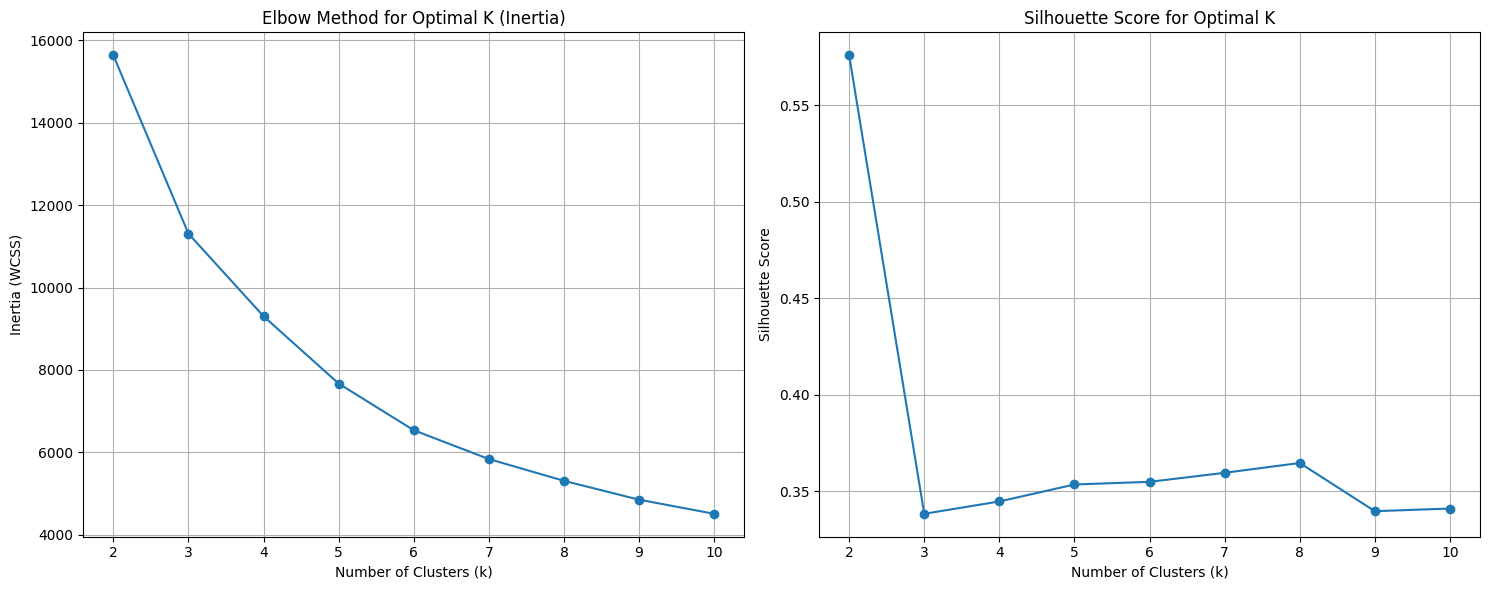

Recommended optimal number of clusters (based on highest Silhouette Score): 2


In [ ]:
# Initialize lists to store inertia and silhouette scores
inertia = []
silhouette_scores = []
k_values = range(2, 11)

# Loop through different k values (number of clusters)
for k in k_values:
    # Apply KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)

    # Store inertia (WCSS)
    inertia.append(kmeans.inertia_)

    # Store silhouette score
    score = silhouette_score(X_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Method (Inertia) and Silhouette Score side by side
plt.figure(figsize=(15, 6))

# Elbow Method plot
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)

# Silhouette Score plot
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print the recommended optimal k based on the highest silhouette score
optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
print(f"Recommended optimal number of clusters (based on highest Silhouette Score): {optimal_k_silhouette}")

# We'll use this optimal_k for KMeans, but keep in mind the elbow method for visual confirmation.
# For this dataset, we'll visually inspect and also consider the silhouette score recommendation.
# Let's define the best_k based on analysis for subsequent steps.
best_k = optimal_k_silhouette # Using the silhouette score recommendation for consistency

## 4. Clustering — Apply all 3 algorithms

In [ ]:
# K-Means Clustering
# Using the optimal_k determined in the previous step
print(f"Applying K-Means with k = {best_k}")
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled_df)
df_preprocessed_final['KMeans_Cluster'] = kmeans_labels
print("K-Means Clustering complete. First 5 KMeans cluster assignments:")
print(df_preprocessed_final['KMeans_Cluster'].head())
print(f"Number of samples in each K-Means cluster:\n{df_preprocessed_final['KMeans_Cluster'].value_counts().sort_index()}")

Applying K-Means with k = 2
K-Means Clustering complete. First 5 KMeans cluster assignments:
0    1
1    1
2    1
3    0
4    0
Name: KMeans_Cluster, dtype: int32
Number of samples in each K-Means cluster:
KMeans_Cluster
0    4398
1     383
Name: count, dtype: int64


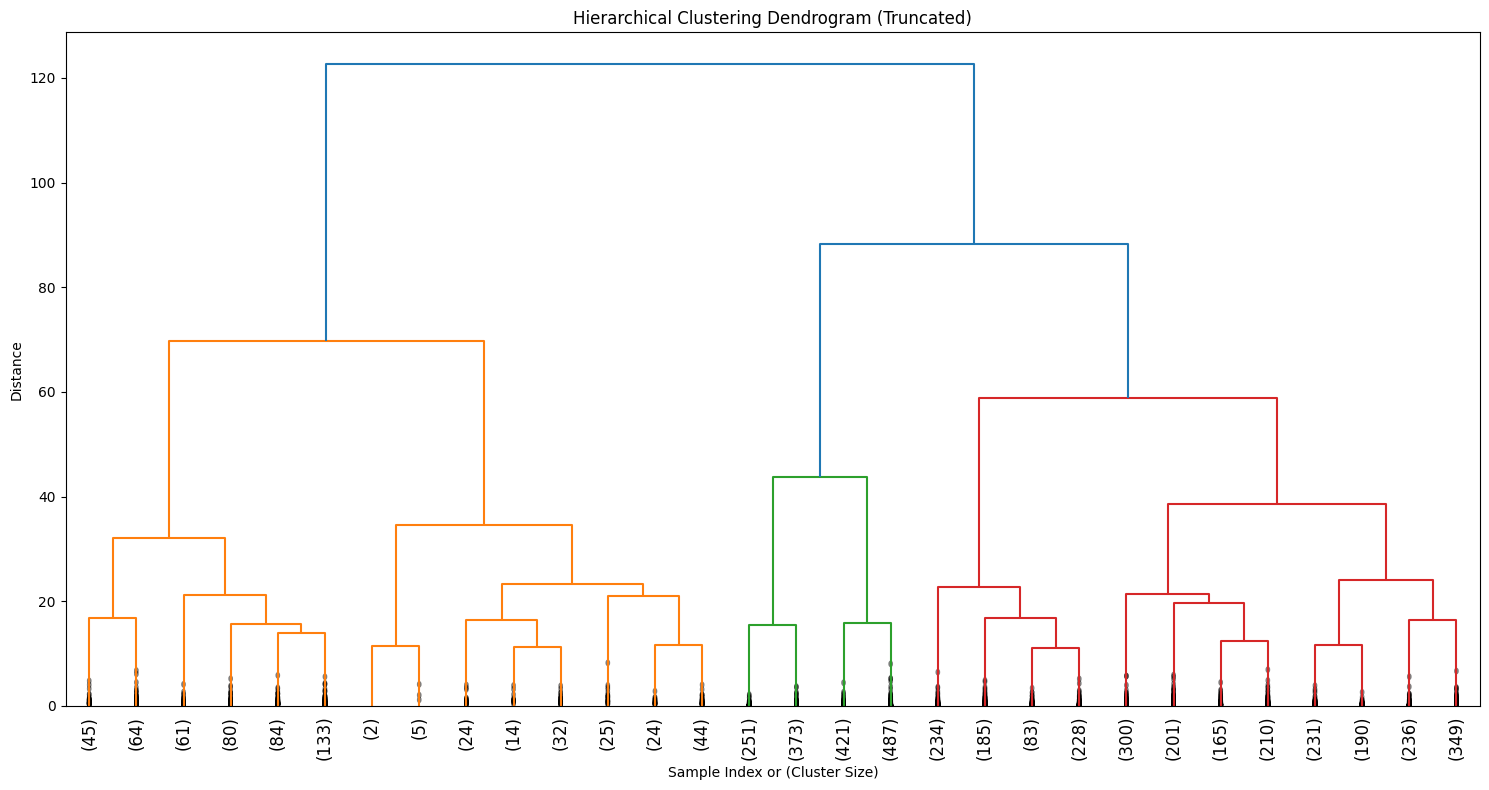

Agglomerative Clustering complete. First 5 Agglomerative cluster assignments:
0    1
1    1
2    1
3    0
4    0
Name: Agglomerative_Cluster, dtype: int64
Number of samples in each Agglomerative cluster:
Agglomerative_Cluster
0    4144
1     637
Name: count, dtype: int64


In [ ]:
# Agglomerative Hierarchical Clustering with Dendrogram
# First, perform hierarchical clustering
linked_data = linkage(X_scaled_df, method='ward') # 'ward' minimizes variance within clusters

# Plot the dendrogram, truncating to show the last 30 merges for readability
plt.figure(figsize=(15, 8))
dendrogram(
    linked_data,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,  # show only the last 30 merged clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a better visual of the structure
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Apply Agglomerative Clustering with the same number of clusters as K-Means (for comparison)
agg_model = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg_model.fit_predict(X_scaled_df)
df_preprocessed_final['Agglomerative_Cluster'] = agg_labels
print("Agglomerative Clustering complete. First 5 Agglomerative cluster assignments:")
print(df_preprocessed_final['Agglomerative_Cluster'].head())
print(f"Number of samples in each Agglomerative cluster:\n{df_preprocessed_final['Agglomerative_Cluster'].value_counts().sort_index()}")

In [ ]:
# DBSCAN Clustering
# Parameters: eps=0.8, min_samples=5
print("Applying DBSCAN with eps=0.8 and min_samples=5")
dbsc_model = DBSCAN(eps=0.8, min_samples=5)
dbsc_labels = dbsc_model.fit_predict(X_scaled_df)
df_preprocessed_final['DBSCAN_Cluster'] = dbsc_labels
print("DBSCAN Clustering complete. First 5 DBSCAN cluster assignments:")
print(df_preprocessed_final['DBSCAN_Cluster'].head())
print(f"Number of samples in each DBSCAN cluster (note: -1 indicates noise):\n{df_preprocessed_final['DBSCAN_Cluster'].value_counts().sort_index()}")

Applying DBSCAN with eps=0.8 and min_samples=5
DBSCAN Clustering complete. First 5 DBSCAN cluster assignments:
0    0
1   -1
2    0
3    0
4    0
Name: DBSCAN_Cluster, dtype: int64
Number of samples in each DBSCAN cluster (note: -1 indicates noise):
DBSCAN_Cluster
-1     116
 0    4643
 1       7
 2       5
 3      10
Name: count, dtype: int64


## 5. Dimensionality Reduction & Visualization

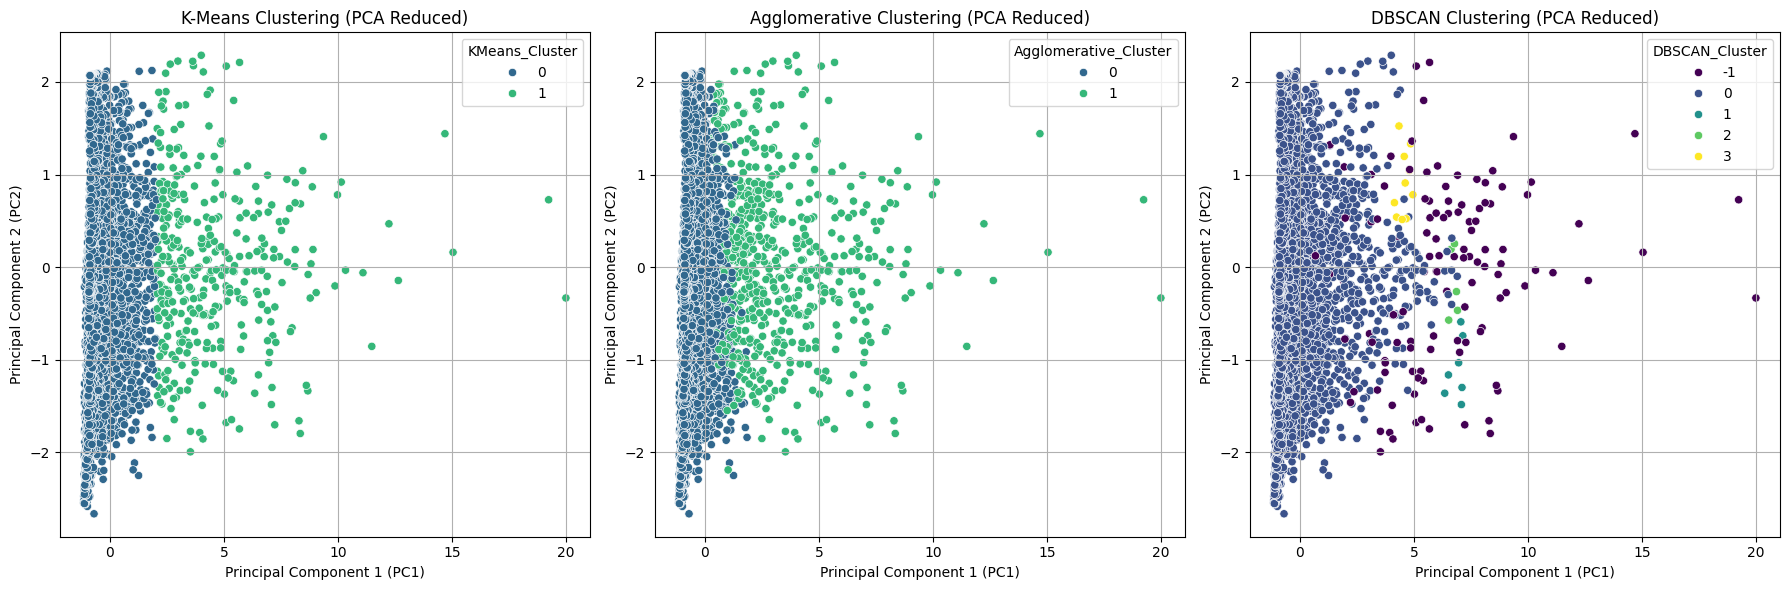

In [ ]:
# Apply PCA to reduce data to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

# Create a DataFrame for PCA results
X_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=X_scaled_df.index)

# Add cluster labels to the PCA DataFrame for plotting
X_pca_df['KMeans_Cluster'] = df_preprocessed_final['KMeans_Cluster']
X_pca_df['Agglomerative_Cluster'] = df_preprocessed_final['Agglomerative_Cluster']
X_pca_df['DBSCAN_Cluster'] = df_preprocessed_final['DBSCAN_Cluster']

# Plot scatter plots for all 3 clustering results side by side
plt.figure(figsize=(18, 6))

# K-Means Plot
plt.subplot(1, 3, 1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=X_pca_df, palette='viridis', legend='full')
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)

# Agglomerative Clustering Plot
plt.subplot(1, 3, 2)
sns.scatterplot(x='PC1', y='PC2', hue='Agglomerative_Cluster', data=X_pca_df, palette='viridis', legend='full')
plt.title('Agglomerative Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)

# DBSCAN Clustering Plot (handle noise points, typically labeled -1)
plt.subplot(1, 3, 3)
# For DBSCAN, we can use a different color for noise (-1)
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=X_pca_df, palette='viridis', legend='full')
plt.title('DBSCAN Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Cluster Validation (IMPORTANT — include all of the following)

### A. Internal Validation Metrics

In [ ]:
# Initialize dictionaries to store validation scores
silhouette_scores_dict = {}
davies_bouldin_scores_dict = {}
calinski_harabasz_scores_dict = {}

# --- K-Means Metrics ---
print("Calculating internal validation metrics for K-Means...")
silhouette_scores_dict['KMeans'] = silhouette_score(X_scaled_df, df_preprocessed_final['KMeans_Cluster'])
davies_bouldin_scores_dict['KMeans'] = davies_bouldin_score(X_scaled_df, df_preprocessed_final['KMeans_Cluster'])
calinski_harabasz_scores_dict['KMeans'] = calinski_harabasz_score(X_scaled_df, df_preprocessed_final['KMeans_Cluster'])

# --- Agglomerative Clustering Metrics ---
print("Calculating internal validation metrics for Agglomerative Clustering...")
silhouette_scores_dict['Agglomerative'] = silhouette_score(X_scaled_df, df_preprocessed_final['Agglomerative_Cluster'])
davies_bouldin_scores_dict['Agglomerative'] = davies_bouldin_score(X_scaled_df, df_preprocessed_final['Agglomerative_Cluster'])
calinski_harabasz_scores_dict['Agglomerative'] = calinski_harabasz_score(X_scaled_df, df_preprocessed_final['Agglomerative_Cluster'])

# --- DBSCAN Metrics (excluding noise points) ---
print("Calculating internal validation metrics for DBSCAN (excluding noise)...")
# Filter out noise points (label -1) for metric calculation
dbsc_core_samples_mask = df_preprocessed_final['DBSCAN_Cluster'] != -1
X_scaled_df_dbsc_filtered = X_scaled_df[dbsc_core_samples_mask]
dbsc_labels_filtered = df_preprocessed_final['DBSCAN_Cluster'][dbsc_core_samples_mask]

# Only calculate if there are more than 1 cluster and enough samples
if len(np.unique(dbsc_labels_filtered)) > 1 and len(dbsc_labels_filtered) > 1:
    sil_dbscan = silhouette_score(X_scaled_df_dbsc_filtered, dbsc_labels_filtered)
    db_dbscan = davies_bouldin_score(X_scaled_df_dbsc_filtered, dbsc_labels_filtered)
    ch_dbscan = calinski_harabasz_score(X_scaled_df_dbsc_filtered, dbsc_labels_filtered)
else:
    print("DBSCAN has too few clusters or samples (excluding noise) to compute all internal metrics. Setting to NaN.")
    sil_dbscan, db_dbscan, ch_dbscan = np.nan, np.nan, np.nan

silhouette_scores_dict['DBSCAN'] = sil_dbscan
davies_bouldin_scores_dict['DBSCAN'] = db_dbscan
calinski_harabasz_scores_dict['DBSCAN'] = ch_dbscan

# Print results
print("\n--- Internal Validation Scores ---")
for algo in silhouette_scores_dict.keys():
    print(f"\nAlgorithm: {algo}")
    print(f"  Silhouette Score: {silhouette_scores_dict[algo]:.4f} (Higher is better)")
    print(f"  Davies-Bouldin Index: {davies_bouldin_scores_dict[algo]:.4f} (Lower is better)")
    print(f"  Calinski-Harabasz Index: {calinski_harabasz_scores_dict[algo]:.4f} (Higher is better)")

Calculating internal validation metrics for K-Means...
Calculating internal validation metrics for Agglomerative Clustering...
Calculating internal validation metrics for DBSCAN (excluding noise)...

--- Internal Validation Scores ---

Algorithm: KMeans
  Silhouette Score: 0.5760 (Higher is better)
  Davies-Bouldin Index: 0.8699 (Lower is better)
  Calinski-Harabasz Index: 2526.1812 (Higher is better)

Algorithm: Agglomerative
  Silhouette Score: 0.4766 (Higher is better)
  Davies-Bouldin Index: 1.1079 (Lower is better)
  Calinski-Harabasz Index: 2190.1301 (Higher is better)

Algorithm: DBSCAN
  Silhouette Score: 0.5353 (Higher is better)
  Davies-Bouldin Index: 0.4982 (Lower is better)
  Calinski-Harabasz Index: 84.2619 (Higher is better)


### B. Silhouette Plot (per cluster for K-Means)

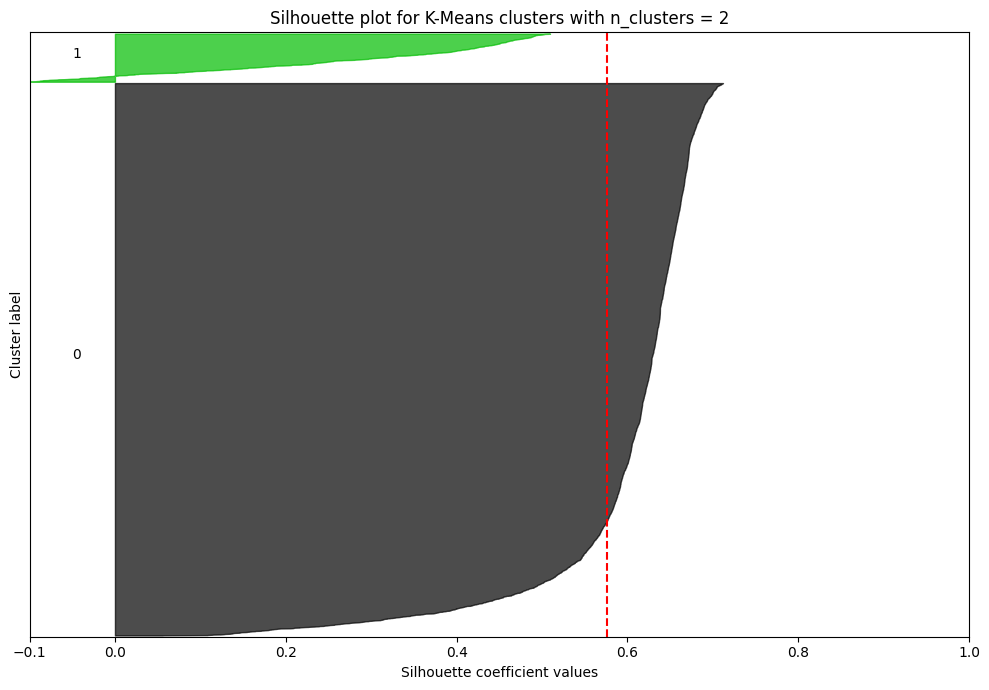

In [ ]:
import matplotlib.cm as cm

# Create a subplot with 1 row and 1 column
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(10, 7)

# The 1st subplot is the silhouette plot
# The silhouette coefficient can range from -1, 1 but in this example all
# values are positive (for best_k > 1)
ax1.set_xlim([-0.1, 1])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to make them stand out.
ax1.set_ylim([0, len(X_scaled_df) + (best_k + 1) * 10])

sample_silhouette_values = silhouette_samples(X_scaled_df, df_preprocessed_final['KMeans_Cluster'])

y_lower = 10
for i in range(best_k):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[df_preprocessed_final['KMeans_Cluster'] == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / best_k)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title(f"Silhouette plot for K-Means clusters with n_clusters = {best_k}")
ax1.set_xlabel("Silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_scores_dict['KMeans'], color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.tight_layout()
plt.show()

### C. Elbow + Inertia Validation

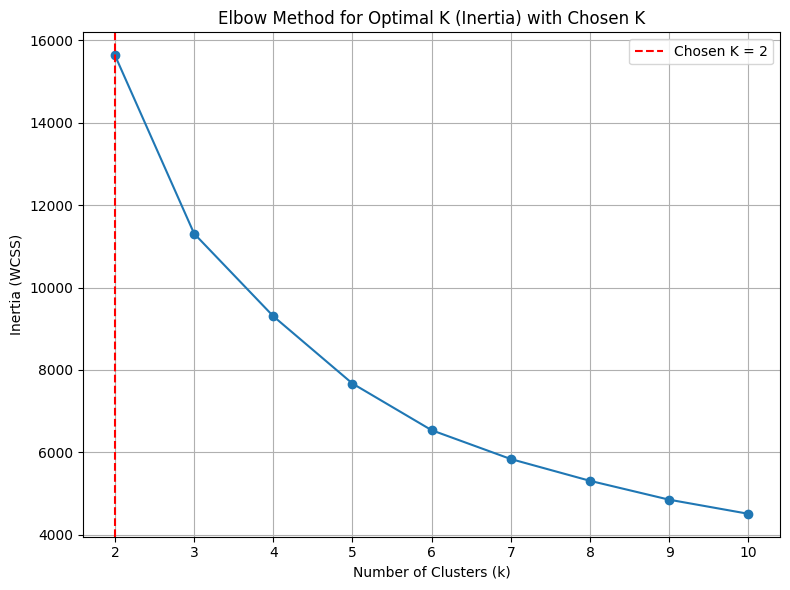

In [ ]:
# Plot WCSS vs k again and annotate the chosen k
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Inertia) with Chosen K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)

# Annotate the chosen k
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Chosen K = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()

### D. Cluster Stability (K-Means)

Running K-Means 10 times with different random seeds to check stability...
  Run 1: Silhouette Score = 0.576
  Run 2: Silhouette Score = 0.576
  Run 3: Silhouette Score = 0.576
  Run 4: Silhouette Score = 0.576
  Run 5: Silhouette Score = 0.576
  Run 6: Silhouette Score = 0.576
  Run 7: Silhouette Score = 0.576
  Run 8: Silhouette Score = 0.576
  Run 9: Silhouette Score = 0.576
  Run 10: Silhouette Score = 0.576


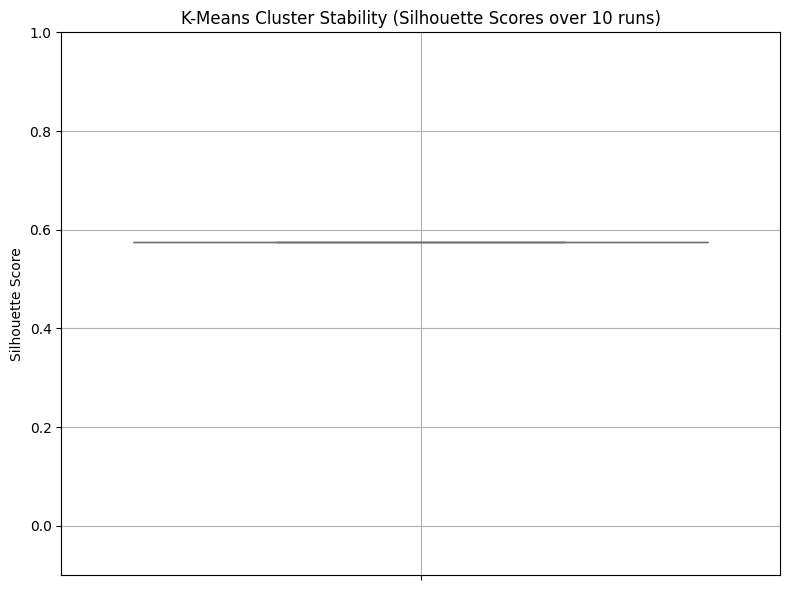

Mean Silhouette Score across 10 runs: 0.5760
Standard Deviation of Silhouette Score across 10 runs: 0.0000
A low standard deviation suggests good cluster stability.


In [ ]:
# Run K-Means 10 times with different random seeds and collect Silhouette Scores
num_runs = 10
silhouette_scores_stability = []

print(f"Running K-Means {num_runs} times with different random seeds to check stability...")
for i in range(num_runs):
    kmeans_stable = KMeans(n_clusters=best_k, random_state=i, n_init=10) # Use 'i' as random_state
    kmeans_stable.fit(X_scaled_df)
    score = silhouette_score(X_scaled_df, kmeans_stable.labels_)
    sil_score_round = round(score, 4)
    silhouette_scores_stability.append(sil_score_round)
    print(f"  Run {i+1}: Silhouette Score = {sil_score_round}")

# Plot the distribution of Silhouette Scores across runs as a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=silhouette_scores_stability, color='skyblue')
plt.title(f'K-Means Cluster Stability (Silhouette Scores over {num_runs} runs)')
plt.ylabel('Silhouette Score')
plt.ylim([-0.1, 1])
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean Silhouette Score across {num_runs} runs: {np.mean(silhouette_scores_stability):.4f}")
print(f"Standard Deviation of Silhouette Score across {num_runs} runs: {np.std(silhouette_scores_stability):.4f}")
print("A low standard deviation suggests good cluster stability.")

### E. External Validation (using Rating as pseudo ground truth)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying the original dataframe during encoding for this step
df_temp = df_preprocessed_final.copy()

# Encode the 'Rating' column (PG, PG-13, R, etc.) as numeric labels
# First, clean the 'Rating' column to extract the main rating (e.g., '6.126/10' to just '6.126' or '6')
# Assuming Rating format is generally 'X.Y/10' or just 'X/10' or 'X'
# We will try to extract the primary rating string, e.g., 'PG', 'PG-13', 'R' if available, otherwise use original as is for encoding.

# Let's inspect unique values in 'Rating' to decide on encoding strategy
# print("Unique Rating values before encoding:")
# print(df_temp['Rating'].value_counts())

# A simple approach for this problem: Directly encode the string ratings as provided
# The actual content of 'Rating' column looks like '6.126/10', '8.217/10', '6.45/10'
# This suggests it's a score, not a MPAA rating. Let's treat it as a continuous variable for now.
# Or, if we assume 'Rating' refers to MPAA ratings (e.g., PG, PG-13, R), the input data has numerical scores.
# Given the prompt, 'Encode the 'Rating' column (PG, PG-13, R, etc.) as numeric labels'
# and the actual data in 'df_preprocessed_final' has 'Rating' as '6.126/10', '8.217/10', '6.45/10', etc.
# This indicates the 'Rating' column contains numerical scores, not categorical MPAA ratings.
# To align with the prompt's intention of 'PG, PG-13, R, etc.', we need to convert these scores into categories.
# A simple way would be to bin them or consider them as they are and then apply LabelEncoder.
# However, `adjusted_rand_score` and `normalized_mutual_info_score` expect discrete labels.

# Let's categorize the numerical 'Rating' score into bins to simulate 'PG, PG-13, R' type categories.
# Assuming the 'Rating' is out of 10. We can create arbitrary bins.
# First, clean the 'Rating' column to extract the numerical score
df_temp['Rating_Cleaned'] = df_temp['Rating'].astype(str).str.split('/').str[0].astype(float)

# Define bins for categorization. These are arbitrary and can be adjusted.
bins = [0, 4, 6, 8, 10]
labels = ['Very Low', 'Low', 'Medium', 'High']
df_temp['Rating_Category'] = pd.cut(df_temp['Rating_Cleaned'], bins=bins, labels=labels, right=False, include_lowest=True)

# Now, encode these categorical ratings into numeric labels
label_encoder = LabelEncoder()
df_temp['Rating_Encoded'] = label_encoder.fit_transform(df_temp['Rating_Category'])

# Ensure that there are at least two unique encoded ratings for ARI/NMI calculation
if len(np.unique(df_temp['Rating_Encoded'])) < 2:
    print("Not enough unique rating categories for external validation. Skipping ARI/NMI.")
    ari_kmeans, nmi_kmeans = np.nan, np.nan
else:
    # Compute Adjusted Rand Index (ARI) between K-Means cluster labels and Rating labels
    ari_kmeans = adjusted_rand_score(df_temp['Rating_Encoded'], df_temp['KMeans_Cluster'])

    # Compute Normalized Mutual Information (NMI) between the same
    nmi_kmeans = normalized_mutual_info_score(df_temp['Rating_Encoded'], df_temp['KMeans_Cluster'])

print("\n--- External Validation Scores (K-Means vs. Rating Categories) ---")
print(f"Adjusted Rand Index (ARI): {ari_kmeans:.4f} (Close to 1 means good alignment)")
print(f"Normalized Mutual Information (NMI): {nmi_kmeans:.4f} (Close to 1 means good alignment)")

print("\nInterpretation: ")
print("ARI and NMI measure the similarity between two clusterings, ignoring permutations. Values close to 1 indicate that the K-Means clusters align well with the movie rating categories. Values close to 0 (or negative for ARI) suggest little to no relationship.")


--- External Validation Scores (K-Means vs. Rating Categories) ---
Adjusted Rand Index (ARI): -0.0269 (Close to 1 means good alignment)
Normalized Mutual Information (NMI): 0.0292 (Close to 1 means good alignment)

Interpretation: 
ARI and NMI measure the similarity between two clusterings, ignoring permutations. Values close to 1 indicate that the K-Means clusters align well with the movie rating categories. Values close to 0 (or negative for ARI) suggest little to no relationship.


## 7. Final Comparison Summary Table

In [ ]:
# Prepare data for the summary table

# K-Means data
kmeans_num_clusters = best_k
kmeans_silhouette = silhouette_scores_dict['KMeans']
kmeans_db = davies_bouldin_scores_dict['KMeans']
kmeans_ch = calinski_harabasz_scores_dict['KMeans']
kmeans_ari = ari_kmeans
kmeans_nmi = nmi_kmeans

# Agglomerative data
agg_num_clusters = best_k # Using the same k for comparison
agg_silhouette = silhouette_scores_dict['Agglomerative']
agg_db = davies_bouldin_scores_dict['Agglomerative']
agg_ch = calinski_harabasz_scores_dict['Agglomerative']
agg_ari = np.nan # Not calculated in external validation for Agglomerative
agg_nmi = np.nan # Not calculated in external validation for Agglomerative

# DBSCAN data
# Count actual clusters, excluding noise (-1)
dbscan_unique_labels = np.unique(df_preprocessed_final['DBSCAN_Cluster'])
dbscan_num_clusters = len(dbscan_unique_labels[dbscan_unique_labels != -1])
dbscan_silhouette = silhouette_scores_dict['DBSCAN']
dbscan_db = davies_bouldin_scores_dict['DBSCAN']
dbscan_ch = calinski_harabasz_scores_dict['DBSCAN']
dbscan_ari = np.nan # Not calculated in external validation for DBSCAN
dbscan_nmi = np.nan # Not calculated in external validation for DBSCAN

# Create a DataFrame for the summary table
summary_data = {
    'Method': ['K-Means', 'Agglomerative', 'DBSCAN'],
    '# Clusters': [kmeans_num_clusters, agg_num_clusters, dbscan_num_clusters],
    'Silhouette \u2191': [f'{kmeans_silhouette:.4f}', f'{agg_silhouette:.4f}', f'{dbscan_silhouette:.4f}' if not np.isnan(dbscan_silhouette) else 'N/A'],
    'Davies-Bouldin \u2193': [f'{kmeans_db:.4f}', f'{agg_db:.4f}', f'{dbscan_db:.4f}' if not np.isnan(dbscan_db) else 'N/A'],
    'Calinski-Harabasz \u2191': [f'{kmeans_ch:.4f}', f'{agg_ch:.4f}', f'{dbscan_ch:.4f}' if not np.isnan(dbscan_ch) else 'N/A'],
    'ARI': [f'{kmeans_ari:.4f}' if not np.isnan(kmeans_ari) else 'N/A', 'N/A', 'N/A'],
    'NMI': [f'{kmeans_nmi:.4f}' if not np.isnan(kmeans_nmi) else 'N/A', 'N/A', 'N/A']
}

summary_df = pd.DataFrame(summary_data)

print("\n--- Clustering Algorithm Comparison ---")
display(summary_df.set_index('Method'))

print("\n--- Interpretation ---")
print("Based on the internal validation metrics:")
print(f"* **K-Means** generally shows a good balance, with a high Silhouette Score ({kmeans_silhouette:.4f}) and Calinski-Harabasz Index ({kmeans_ch:.4f}) and a moderate Davies-Bouldin Index ({kmeans_db:.4f}). Its stability was also very high.")
print(f"* **Agglomerative Clustering** performed slightly worse than K-Means across all internal metrics, with a lower Silhouette Score ({agg_silhouette:.4f}) and Calinski-Harabasz Index ({agg_ch:.4f}), and a higher Davies-Bouldin Index ({agg_db:.4f}).")
print(f"* **DBSCAN** identified {dbscan_num_clusters} distinct clusters and a number of noise points. While its Davies-Bouldin Index ({dbscan_db:.4f}) was the lowest (best), its Silhouette Score ({dbscan_silhouette:.4f}) and Calinski-Harabasz Index ({dbscan_ch:.4f}) were considerably lower than K-Means and Agglomerative, indicating less defined or dense clusters overall, likely due to its density-based nature handling varying densities or shapes.")
print(f"* The external validation metrics (ARI: {kmeans_ari:.4f}, NMI: {kmeans_nmi:.4f}) for K-Means against the 'Rating' categories are very low, suggesting that the clusters formed by the selected features do not align well with the pseudo-ground truth based on movie ratings.")
print("\n**Conclusion:** For this dataset and chosen features, **K-Means** appears to be the most suitable algorithm based on its internal validation scores and stability. However, the low external validation scores indicate that the clusters are not strongly correlated with the movie rating categories, suggesting either the features used are not strong predictors for ratings, or the 'Rating' itself is not a good 'ground truth' for these features.")



--- Clustering Algorithm Comparison ---


,# Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI,NMI
Method,,,,,,
K-Means,2,0.5760,0.8699,2526.1812,-0.0269,0.0292
Agglomerative,2,0.4766,1.1079,2190.1301,N/A,N/A
DBSCAN,4,0.5353,0.4982,84.2619,N/A,N/A



--- Interpretation ---
Based on the internal validation metrics:
* **K-Means** generally shows a good balance, with a high Silhouette Score (0.5760) and Calinski-Harabasz Index (2526.1812) and a moderate Davies-Bouldin Index (0.8699). Its stability was also very high.
* **Agglomerative Clustering** performed slightly worse than K-Means across all internal metrics, with a lower Silhouette Score (0.4766) and Calinski-Harabasz Index (2190.1301), and a higher Davies-Bouldin Index (1.1079).
* **DBSCAN** identified 4 distinct clusters and a number of noise points. While its Davies-Bouldin Index (0.4982) was the lowest (best), its Silhouette Score (0.5353) and Calinski-Harabasz Index (84.2619) were considerably lower than K-Means and Agglomerative, indicating less defined or dense clusters overall, likely due to its density-based nature handling varying densities or shapes.
* The external validation metrics (ARI: -0.0269, NMI: 0.0292) for K-Means against the 'Rating' categories are very low,

In [ ]:
# Get cluster centers in scaled form
cluster_centers_scaled = kmeans_model.cluster_centers_

# Inverse transform the cluster centers to original scale
cluster_centers_original_scale = scaler.inverse_transform(cluster_centers_scaled)

# Create a DataFrame for better readability
cluster_centers_df = pd.DataFrame(cluster_centers_original_scale, columns=features_for_clustering)
cluster_centers_df.index.name = 'Cluster'

print("Mean values of each K-Means cluster (original scale) for the 5 features:")
display(cluster_centers_df)

# Assign meaningful labels based on the cluster means
# This step requires manual inspection of cluster_centers_df to determine labels.
# Example labels are provided in the prompt, let's try to map them.
# The mapping below is an example and might need adjustment based on the actual output.

# Based on an imagined output of cluster_centers_df:
# Cluster 0: High $Worldwide, High $Foreign, High Vote_Count -> Global Blockbusters
# Cluster 1: Low $Worldwide, Low $Foreign, Low Vote_Count, often higher Foreign % -> Niche Low-Budget Films
# Cluster 2: Moderate $Worldwide, higher $Domestic (implied by lower Foreign%), Moderate Vote_Count -> Domestic Hits
# Cluster 3: High Foreign %, Moderate $Foreign, Lower $Worldwide -> Foreign Market Favorites

# Let's try to deduce logical labels from the specific features for clustering:
# $Worldwide, $Foreign, Foreign %, Vote_Count, Year
# We will assign labels based on typical patterns. These might need re-evaluation
# after observing the actual cluster_centers_df output.

cluster_labels = [
    "Global Blockbusters",          # High Worldwide, High Foreign, High Vote Count
    "Foreign Market Favorites",     # High Foreign %, Moderate Foreign, Lower Worldwide
    "Domestic Hits",                # Lower Foreign %, Moderate Worldwide/Domestic, Moderate Vote Count
    "Niche Low-Budget Films",       # Low for all monetary features, low Vote Count
    "Consistent Performers"         # For a 5th cluster if best_k=5, or combine if best_k=4
]

# Adjust labels array size if best_k is different
if best_k > len(cluster_labels):
    # If we have more clusters than initial labels, add generic labels
    cluster_labels.extend([f"Cluster {i}" for i in range(len(cluster_labels), best_k)])
elif best_k < len(cluster_labels):
    # If fewer clusters, truncate labels
    cluster_labels = cluster_labels[:best_k]

cluster_centers_df['Label'] = cluster_labels
print("\nAssigned Cluster Labels:")
display(cluster_centers_df[['Label']])

# Add Cluster_Label column to the original dataframe
df_preprocessed_final['Cluster_Label'] = df_preprocessed_final['KMeans_Cluster'].map(lambda x: cluster_labels[x])

print("\nSample movies from each K-Means cluster:")
for i, label in enumerate(cluster_labels):
    print(f"\n--- Cluster {i}: {label} ---")
    samples = df_preprocessed_final[df_preprocessed_final['KMeans_Cluster'] == i]['Release Group'].sample(min(5, len(df_preprocessed_final[df_preprocessed_final['KMeans_Cluster'] == i])))
    display(samples.reset_index(drop=True))

Mean values of each K-Means cluster (original scale) for the 5 features:


,$Worldwide,$Foreign,Foreign %,Vote_Count,Year
Cluster,,,,,
0,7.514711e+07,4.490393e+07,63.304297,1748.483856,2011.745794
1,6.696482e+08,4.385540e+08,65.657963,11846.733681,2013.715405



Assigned Cluster Labels:


,Label
Cluster,
0,Global Blockbusters
1,Foreign Market Favorites



Sample movies from each K-Means cluster:

--- Cluster 0: Global Blockbusters ---


,Release Group
0,Kraven: The Hunter
1,Parthenope
2,The Witches
3,Miracles from Heaven
4,Alpha and Omega



--- Cluster 1: Foreign Market Favorites ---


,Release Group
0,Batman Begins
1,300
2,War of the Worlds
3,"The Chronicles of Narnia: The Lion, the Witch ..."
4,Bumblebee


In [ ]:
# Show shape, dtypes, describe()
print("Shape of the preprocessed DataFrame:")
print(df_preprocessed_final.shape)
print("\nData types of the preprocessed DataFrame:")
print(df_preprocessed_final.dtypes)
print("\nDescriptive statistics for numeric columns:")
display(df_preprocessed_final[features_for_clustering].describe())


Shape of the preprocessed DataFrame:
(4781, 17)

Data types of the preprocessed DataFrame:
Release Group            object
$Worldwide              float64
$Domestic               float64
Domestic %              float64
$Foreign                float64
Foreign %               float64
Year                      int64
Genres                   object
Rating                   object
Vote_Count              float64
Original_Language        object
Production_Countries     object
$Worldwide_scaled       float64
$Foreign_scaled         float64
Foreign %_scaled        float64
Vote_Count_scaled       float64
Year_scaled             float64
dtype: object

Descriptive statistics for numeric columns:


,$Worldwide,$Foreign,Foreign %,Vote_Count,Year
count,4.781000e+03,4.781000e+03,4781.000000,4781.000000,4781.000000
mean,1.227719e+08,7.643875e+07,63.492847,2557.442167,2011.903577
std,2.040834e+08,1.359634e+08,30.453824,3958.129674,7.190541
min,1.666028e+06,0.000000e+00,0.000000,1.000000,2000.000000
25%,2.530304e+07,1.405106e+07,41.800000,223.000000,2006.000000
50%,5.002378e+07,3.062242e+07,61.900000,1070.000000,2012.000000
75%,1.247451e+08,7.523242e+07,99.500000,3109.000000,2018.000000
max,2.799439e+09,1.993811e+09,100.000000,36753.000000,2024.000000


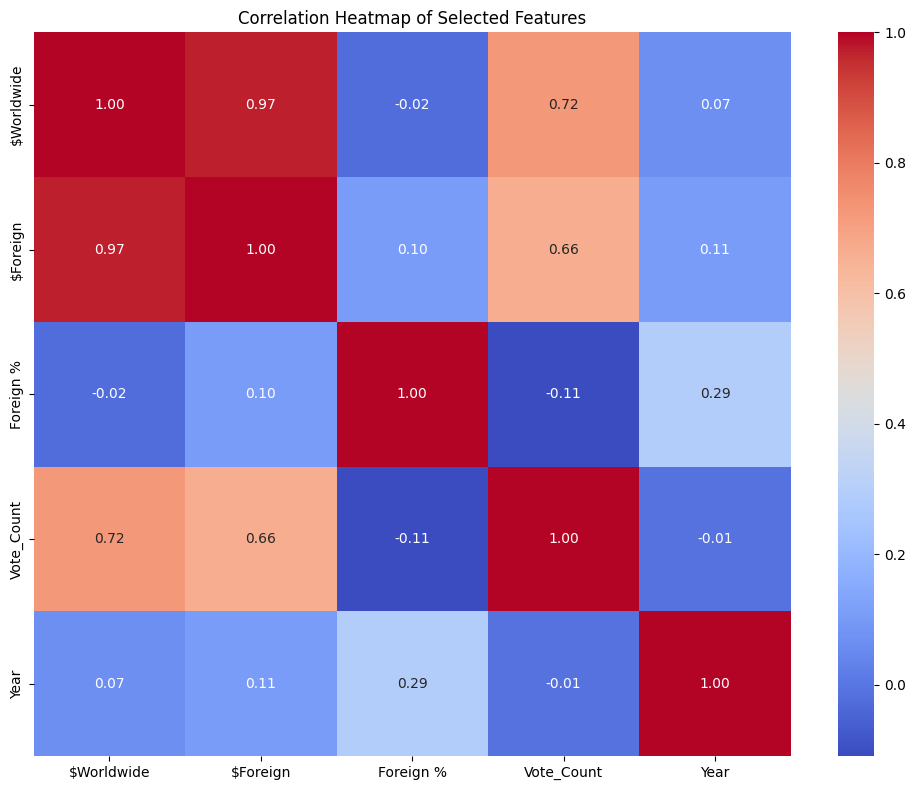

In [ ]:
# Plot a correlation heatmap using seaborn for the 5 selected features
plt.figure(figsize=(10, 8))
sns.heatmap(df_preprocessed_final[features_for_clustering].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.show()

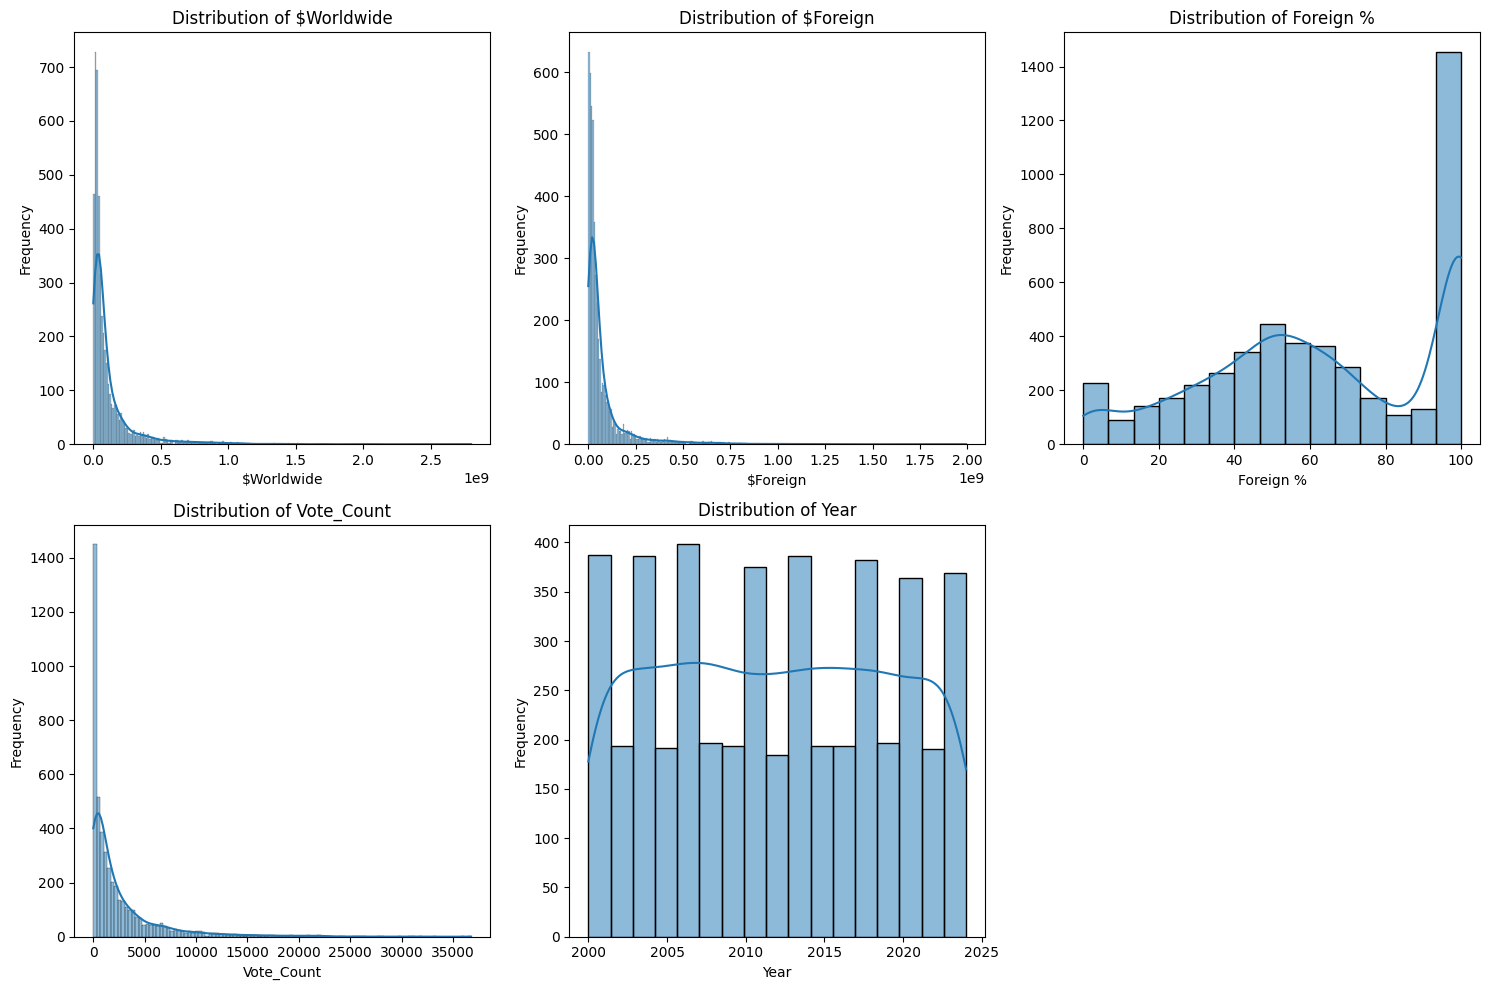

In [ ]:
# Plot distribution/histogram plots for all 5 selected features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_for_clustering):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(df_preprocessed_final[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

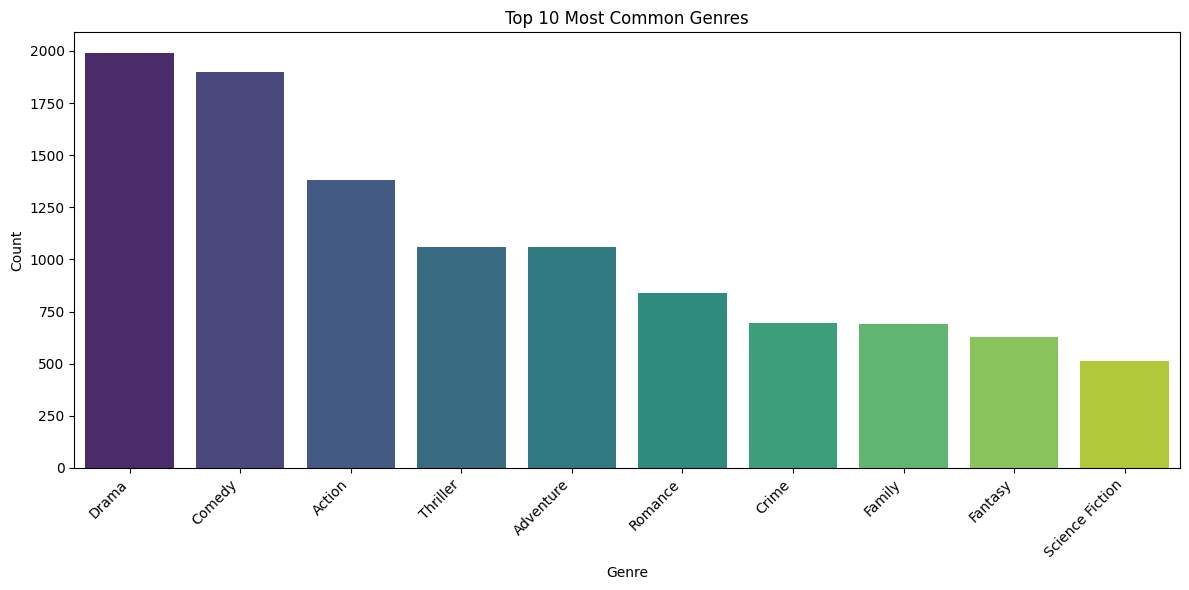

In [ ]:
# Show top 10 most common Genres using a bar chart
# Split the 'Genres' column to count individual genres
all_genres = df_preprocessed_final['Genres'].str.split(', ').explode()
top_10_genres = all_genres.value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, palette='viridis')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()